In [ ]:
!pip install ultralytics opencv-python-headless matplotlib --quiet
!pip install pillow requests --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.5 MB/s eta 0:00:00


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from PIL import Image
from ultralytics import YOLO
import os

print("All libraries imported successfully!")
print(f"OpenCV version: {cv2.__version__}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
All libraries imported successfully!
OpenCV version: 4.13.0


### Helper Function: Load Image from URL
This helper function downloads images directly from the internet — no manual file uploads needed!

In [ ]:
def load_image_from_url(url, save_path=None):
    """Download an image from a URL and load it with OpenCV.

    Args:
        url: Direct URL to the image
        save_path: Optional path to save the downloaded image locally

    Returns:
        OpenCV BGR image array
    """
    response = requests.get(url, timeout=15)
    response.raise_for_status()

    img_array = np.frombuffer(response.content, dtype=np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

    if save_path:
        cv2.imwrite(save_path, img)
        print(f"Image saved to: {save_path}")

    return img


def show_image(img_bgr, title="Image", figsize=(10, 8)):
    """Display a BGR OpenCV image using matplotlib."""
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


print("Helper functions defined successfully!")

Helper functions defined successfully!


Image saved to: classroom.jpg

0: 448x640 14 persons, 2 handbags, 1 bottle, 1 tv, 10.1ms
Speed: 1.7ms preprocess, 10.1ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)


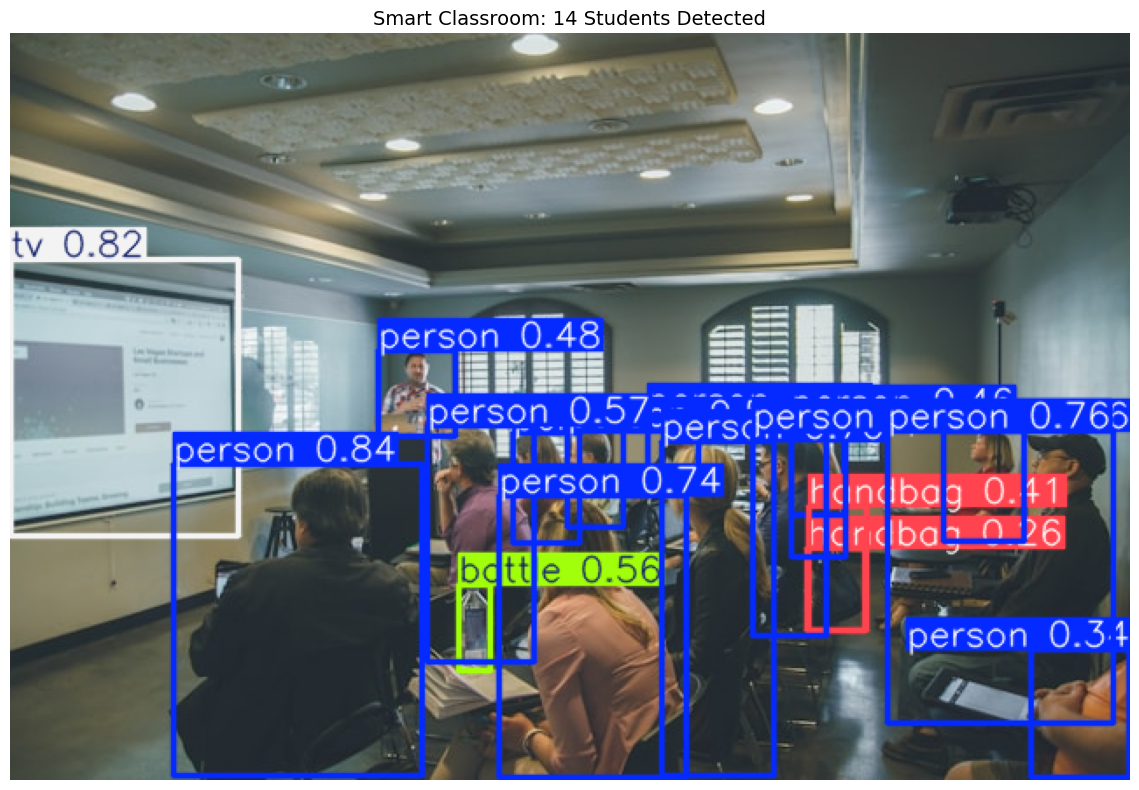


📋 Attendance Log:
------------------------------------------------------------
ID    Confidence      Timestamp                 Status
------------------------------------------------------------
1     0.84            2026-04-17 15:19:00       Present
2     0.76            2026-04-17 15:19:00       Present
3     0.74            2026-04-17 15:19:00       Present
4     0.74            2026-04-17 15:19:00       Present
5     0.70            2026-04-17 15:19:00       Present
6     0.57            2026-04-17 15:19:00       Present
7     0.57            2026-04-17 15:19:00       Present
8     0.48            2026-04-17 15:19:00       Present
9     0.46            2026-04-17 15:19:00       Present
10    0.46            2026-04-17 15:19:00       Present
11    0.36            2026-04-17 15:19:00       Present
12    0.34            2026-04-17 15:19:00       Present
13    0.30            2026-04-17 15:19:00       Present
14    0.29            2026-04-17 15:19:00       Present
--------------------

In [ ]:
import datetime

classroom_url = "https://images.unsplash.com/photo-1524178232363-1fb2b075b655?w=640"  # Classroom
try:
    classroom_img = load_image_from_url(classroom_url, save_path="classroom.jpg")
except:

    classroom_img = load_image_from_url("https://ultralytics.com/images/bus.jpg", save_path="classroom.jpg")

model_classroom = YOLO("yolov8n.pt")
results_classroom = model_classroom(classroom_img)

person_count = 0
attendance_log = []

for box in results_classroom[0].boxes:
    cls_id = int(box.cls[0])
    class_name = model_classroom.names[cls_id]
    if class_name == "person":
        person_count += 1
        confidence = float(box.conf[0])
        timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        attendance_log.append({
            'id': person_count,
            'confidence': confidence,
            'timestamp': timestamp,
            'status': 'Present'
        })

annotated_classroom = results_classroom[0].plot()
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(annotated_classroom, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f"Smart Classroom: {person_count} Students Detected", fontsize=14)
plt.tight_layout()
plt.show()

print("\n📋 Attendance Log:")
print("-" * 60)
print(f"{'ID':<5} {'Confidence':<15} {'Timestamp':<25} {'Status'}")
print("-" * 60)
for entry in attendance_log:
    print(f"{entry['id']:<5} {entry['confidence']:<15.2f} {entry['timestamp']:<25} {entry['status']}")
print("-" * 60)
print(f"Total Present: {person_count}")

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

gray_classroom = cv2.cvtColor(classroom_img, cv2.COLOR_BGR2GRAY)
faces_classroom = face_cascade.detectMultiScale(gray_classroom, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
print(f"\nFaces detected by Haar Cascade: {len(faces_classroom)}")

In [ ]:
!apt-get install -y tesseract-ocr --quiet
!pip install pytesseract --quiet

import pytesseract

print("Tesseract OCR installed!")

Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.
Tesseract OCR installed!


Image saved to: parking.jpg

0: 448x640 (no detections), 13.7ms
Speed: 2.4ms preprocess, 13.7ms inference, 2.0ms postprocess per image at shape (1, 3, 448, 640)


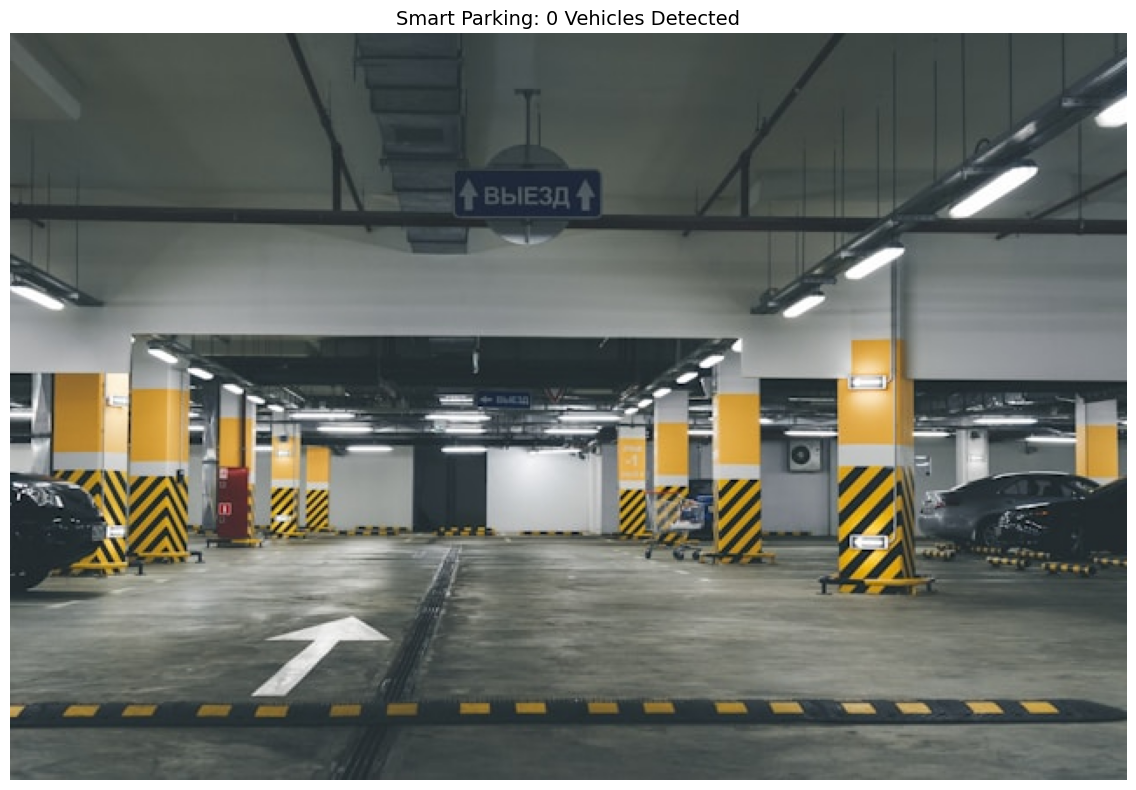


Vehicle Detection Report:
--------------------------------------------------

Parking Status:
  Total Slots: 20
  Occupied: 0
  Available: 20
No license plate candidates found in this image.


In [ ]:
parking_url = "https://images.unsplash.com/photo-1590674899484-d5640e854abe?w=640"
try:
    parking_img = load_image_from_url(parking_url, save_path="parking.jpg")
except:
    parking_img = load_image_from_url("https://ultralytics.com/images/bus.jpg", save_path="parking.jpg")

model_parking = YOLO("yolov8n.pt")
results_parking = model_parking(parking_img)

vehicle_classes = {"car", "truck", "bus", "motorcycle", "bicycle"}
vehicle_count = 0
vehicle_details = []
total_slots = 20

for box in results_parking[0].boxes:
    cls_id = int(box.cls[0])
    class_name = model_parking.names[cls_id]
    confidence = float(box.conf[0])
    if class_name in vehicle_classes:
        vehicle_count += 1
        vehicle_details.append({'type': class_name, 'confidence': confidence})

annotated_parking = results_parking[0].plot()
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(annotated_parking, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f"Smart Parking: {vehicle_count} Vehicles Detected", fontsize=14)
plt.tight_layout()
plt.show()

print("\nVehicle Detection Report:")
print("-" * 50)
for i, v in enumerate(vehicle_details):
    print(f"  Vehicle {i+1}: {v['type']} (Confidence: {v['confidence']:.2f})")

print(f"\nParking Status:")
print(f"  Total Slots: {total_slots}")
print(f"  Occupied: {vehicle_count}")
print(f"  Available: {total_slots - vehicle_count}")

gray_parking = cv2.cvtColor(parking_img, cv2.COLOR_BGR2GRAY)

blur = cv2.bilateralFilter(gray_parking, 11, 17, 17)
edged = cv2.Canny(blur, 30, 200)

contours, _ = cv2.findContours(edged.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contours = sorted(contours, key=cv2.contourArea, reverse=True)[:10]

plate_candidates = []
for c in contours:
    peri = cv2.arcLength(c, True)
    approx = cv2.approxPolyDP(c, 0.018 * peri, True)
    if len(approx) == 4:
        x, y, w, h = cv2.boundingRect(approx)
        aspect_ratio = w / float(h)
        if 2.0 < aspect_ratio < 6.0 and w > 60:
            plate_candidates.append((x, y, w, h))
plate_img = parking_img.copy()
for (x, y, w, h) in plate_candidates[:3]:
    cv2.rectangle(plate_img, (x, y), (x+w, y+h), (0, 255, 0), 2)
    plate_roi = gray_parking[y:y+h, x:x+w]
    try:
        plate_text = pytesseract.image_to_string(plate_roi, config='--psm 7').strip()
        cv2.putText(plate_img, f"Plate: {plate_text}", (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
        print(f"  License Plate Text: {plate_text}")
    except:
        pass

if plate_candidates:
    show_image(plate_img, title="License Plate Detection", figsize=(12, 8))
else:
    print("No license plate candidates found in this image.")

Image saved to: wildlife_0.jpg

0: 384x640 1 elephant, 15.0ms
Speed: 4.4ms preprocess, 15.0ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)
Image saved to: wildlife_1.jpg

0: 448x640 (no detections), 23.4ms
Speed: 3.9ms preprocess, 23.4ms inference, 2.7ms postprocess per image at shape (1, 3, 448, 640)
Image saved to: wildlife_2.jpg

0: 640x448 1 bird, 112.7ms
Speed: 3.5ms preprocess, 112.7ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 448)


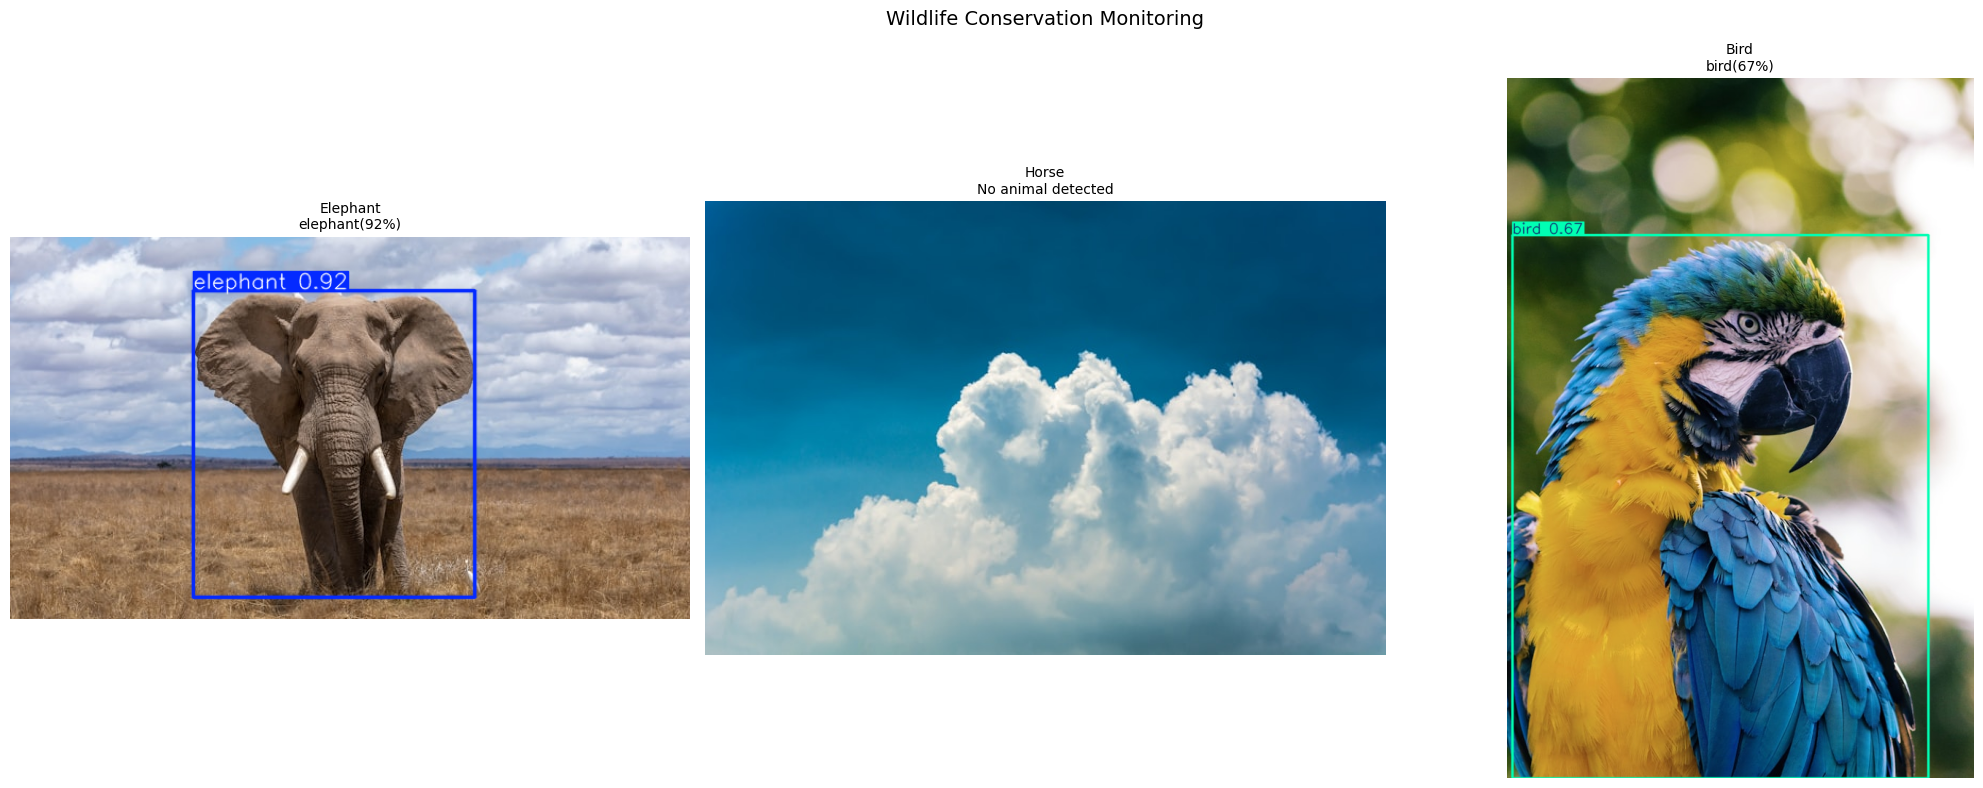


Wildlife Detection Report:
----------------------------------------------------------------------
Expected        Detected        Confidence      Timestamp
----------------------------------------------------------------------
Elephant        elephant        0.92            2026-04-17 15:19:21
Bird            bird            0.67            2026-04-17 15:19:22


In [ ]:
wildlife_urls = {
    "Elephant": "https://images.unsplash.com/photo-1557050543-4d5f4e07ef46?w=640",
    "Horse": "https://images.unsplash.com/photo-1509803874385-db7c23652552?w=640",
    "Bird": "https://images.unsplash.com/photo-1452570053594-1b985d6ea890?w=640",
}

model_wildlife = YOLO("yolov8n.pt")
animal_classes = {"bird", "cat", "dog", "horse", "sheep", "cow", "elephant",
                  "bear", "zebra", "giraffe"}
wildlife_report = []
fig, axes = plt.subplots(1, len(wildlife_urls), figsize=(7 * len(wildlife_urls), 8))
if len(wildlife_urls) == 1:
    axes = [axes]
for idx, (species, url) in enumerate(wildlife_urls.items()):
    try:
        img = load_image_from_url(url, save_path=f"wildlife_{idx}.jpg")
        results = model_wildlife(img)
        annotated = results[0].plot()
        detected_animals = []
        for box in results[0].boxes:
            cls_name = model_wildlife.names[int(box.cls[0])]
            conf = float(box.conf[0])
            if cls_name in animal_classes:
                detected_animals.append((cls_name, conf))
                wildlife_report.append({
                    'expected': species,
                    'detected': cls_name,
                    'confidence': conf,
                    'timestamp': datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                })
        n_animals = len(detected_animals)
        title = f"{species}\n{', '.join([f'{a}({c:.0%})' for a, c in detected_animals]) if detected_animals else 'No animal detected'}"
        axes[idx].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        axes[idx].set_title(title, fontsize=10)
        axes[idx].axis('off')
    except Exception as e:
        axes[idx].text(0.5, 0.5, f"Error: {str(e)[:30]}", ha='center', va='center')
        axes[idx].axis('off')
plt.suptitle("Wildlife Conservation Monitoring", fontsize=14)
plt.tight_layout()
plt.show()
print("\nWildlife Detection Report:")
print("-" * 70)
print(f"{'Expected':<15} {'Detected':<15} {'Confidence':<15} {'Timestamp'}")
print("-" * 70)
for entry in wildlife_report:
    print(f"{entry['expected']:<15} {entry['detected']:<15} {entry['confidence']:<15.2f} {entry['timestamp']}")

Image saved to: fabric.jpg

0: 640x448 1 suitcase, 1 chair, 6.6ms
Speed: 2.0ms preprocess, 6.6ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 448)


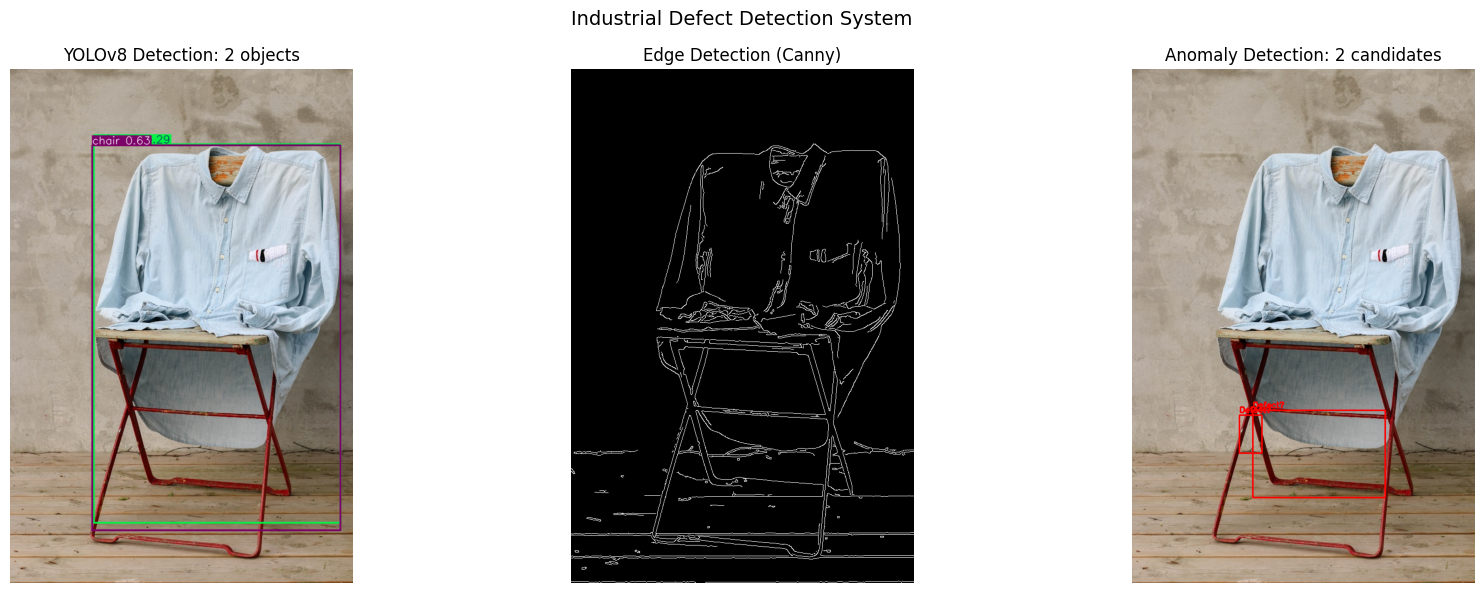


Quality Control Statistics:
  Total anomaly candidates: 2
  Large objects detected (YOLO): 2
  Status: FLAGGED - Review Required


In [ ]:
# Case Study 4: Industrial Defect Detection System
# Using YOLOv8 for general object detection + anomaly detection approach

from skimage import exposure

# Download a texture/fabric image
fabric_url = "https://images.unsplash.com/photo-1558171813-4c088753af8f?w=640"  # Fabric texture
try:
    fabric_img = load_image_from_url(fabric_url, save_path="fabric.jpg")
except:
    fabric_img = load_image_from_url("https://ultralytics.com/images/bus.jpg", save_path="fabric.jpg")


model_defect = YOLO("yolov8n.pt")
results_defect = model_defect(fabric_img)
annotated_defect = results_defect[0].plot()
gray_fabric = cv2.cvtColor(fabric_img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray_fabric, (5, 5), 0)
edges = cv2.Canny(blurred, 50, 150)
contours, _ = cv2.findContours(edges.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

defect_contours = []
min_defect_area = 500
max_defect_area = 10000

for cnt in contours:
    area = cv2.contourArea(cnt)
    if min_defect_area < area < max_defect_area:
        defect_contours.append(cnt)
defect_img = fabric_img.copy()
for cnt in defect_contours:
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(defect_img, (x, y), (x+w, y+h), (0, 0, 255), 2)
    cv2.putText(defect_img, "Defect?", (x, y-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(cv2.cvtColor(annotated_defect, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"YOLOv8 Detection: {len(results_defect[0].boxes)} objects")
axes[0].axis('off')

axes[1].imshow(edges, cmap='gray')
axes[1].set_title("Edge Detection (Canny)")
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(defect_img, cv2.COLOR_BGR2RGB))
axes[2].set_title(f"Anomaly Detection: {len(defect_contours)} candidates")
axes[2].axis('off')

plt.suptitle("Industrial Defect Detection System", fontsize=14)
plt.tight_layout()
plt.show()

# Quality control statistics
print("\nQuality Control Statistics:")
print(f"  Total anomaly candidates: {len(defect_contours)}")
print(f"  Large objects detected (YOLO): {len(results_defect[0].boxes)}")
status = "FLAGGED - Review Required" if len(defect_contours) > 0 else "PASSED - No Defects Detected"
print(f"  Status: {status}")

Image saved to: shelf.jpg

0: 480x640 (no detections), 43.9ms
Speed: 1.2ms preprocess, 43.9ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)


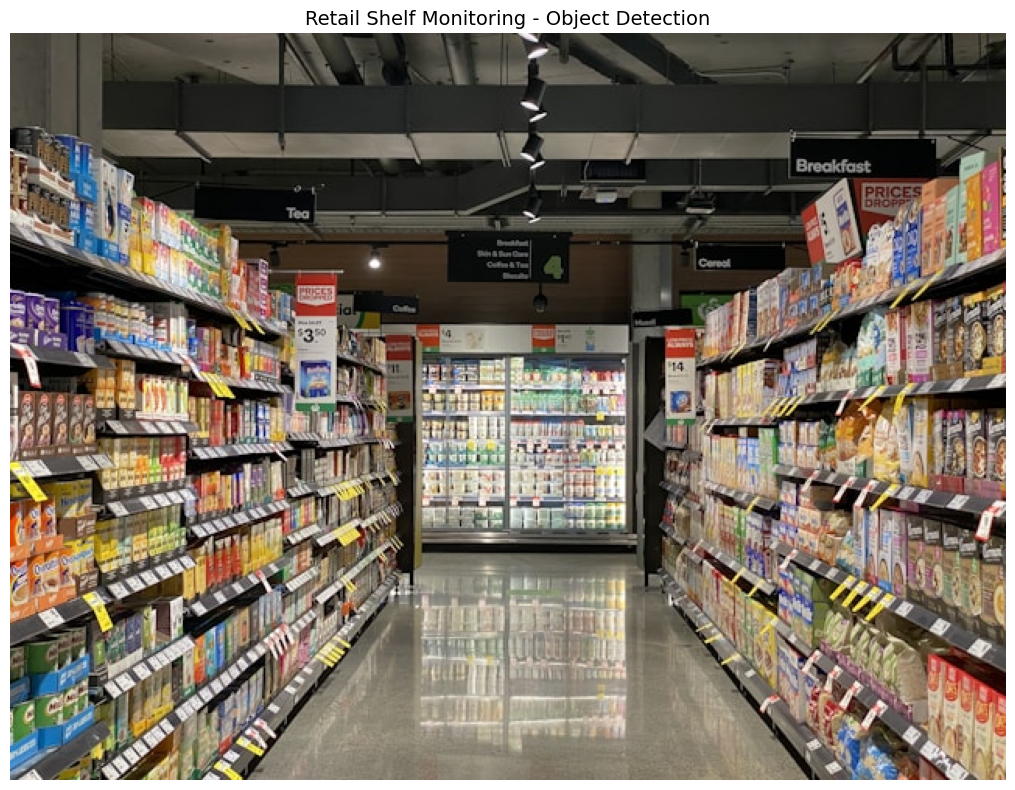


       RETAIL STORE ANALYTICS REPORT

Products on shelf: 0

Furniture items: 0
Other objects: 0

Shelf Status: NEEDS RESTOCKING
Report generated: 2026-04-17 15:19:28


In [ ]:
# Case Study 5: Retail Store Analytics with Shelf Monitoring

# Download a retail/shelf image
shelf_url = "https://images.unsplash.com/photo-1604719312566-8912e9227c6a?w=640"  # Store shelves
try:
    shelf_img = load_image_from_url(shelf_url, save_path="shelf.jpg")
except:
    shelf_img = load_image_from_url("https://ultralytics.com/images/bus.jpg", save_path="shelf.jpg")

model_shelf = YOLO("yolov8n.pt")
results_shelf = model_shelf(shelf_img)
product_classes = {"bottle", "cup", "wine glass", "bowl", "banana", "apple",
                    "orange", "pizza", "donut", "cake", "sandwich", "book", "vase"}
furniture_classes = {"chair", "couch", "dining table"}

product_count = 0
furniture_count = 0
other_count = 0
product_list = []

for box in results_shelf[0].boxes:
    cls_name = model_shelf.names[int(box.cls[0])]
    conf = float(box.conf[0])
    if cls_name in product_classes:
        product_count += 1
        product_list.append((cls_name, conf))
    elif cls_name in furniture_classes:
        furniture_count += 1
    else:
        other_count += 1

# Display results
annotated_shelf = results_shelf[0].plot()
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(annotated_shelf, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Retail Shelf Monitoring - Object Detection", fontsize=14)
plt.tight_layout()
plt.show()

# Generate store report
print("\n" + "="*50)
print("       RETAIL STORE ANALYTICS REPORT")
print("="*50)
print(f"\nProducts on shelf: {product_count}")
for item, conf in product_list:
    print(f"  - {item} (confidence: {conf:.2f})")
print(f"\nFurniture items: {furniture_count}")
print(f"Other objects: {other_count}")
print(f"\nShelf Status: {'WELL STOCKED' if product_count > 3 else 'NEEDS RESTOCKING'}")
print(f"Report generated: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")